# Target Customer Prediction

In [2]:
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


## Load Data

In [3]:
df=pd.read_csv('target_customer.csv')

In [4]:
le = LabelEncoder()
df['gender_encoded'] = le.fit_transform(df['gender'])
# M: 1, F: 0, O: 2

In [5]:
df.drop(columns=['gender'], inplace=True)
df.rename(columns={'gender_encoded': 'gender'}, inplace=True)

In [6]:
df['offer_completed_rate'] = df['offer_completed'] / df['offer_received']

In [7]:
df

,id,age,income,member_days,offer_completed,offer_received,gender,offer_completed_rate
0,0009655768c64bdeb2e877511632db8f,33,72000.0,3243,3,5,1,0.60
1,0011e0d4e6b944f998e987f904e8c1e5,40,57000.0,2980,3,5,2,0.60
2,0020c2b971eb4e9188eac86d93036a77,59,90000.0,3656,3,5,0,0.60
3,0020ccbbb6d84e358d3414a3ff76cffd,24,60000.0,3404,3,4,0,0.75
4,003d66b6608740288d6cc97a6903f4f0,26,73000.0,3182,3,5,0,0.60
...,...,...,...,...,...,...,...,...
14820,fff3ba4757bd42088c044ca26d73817a,69,83000.0,3822,3,6,0,0.50
14821,fff7576017104bcc8677a8d63322b5e1,71,73000.0,3050,3,5,1,0.60
14822,fff8957ea8b240a6b5e634b6ee8eafcf,71,56000.0,2940,0,3,1,0.00
14823,fffad4f4828548d1b5583907f2e9906b,34,34000.0,3331,3,4,1,0.75


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14825 entries, 0 to 14824
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    14825 non-null  object 
 1   age                   14825 non-null  int64  
 2   income                14825 non-null  float64
 3   member_days           14825 non-null  int64  
 4   offer_completed       14825 non-null  int64  
 5   offer_received        14825 non-null  int64  
 6   gender                14825 non-null  int64  
 7   offer_completed_rate  14820 non-null  float64
dtypes: float64(2), int64(5), object(1)
memory usage: 926.7+ KB


In [9]:
df[df['offer_completed_rate'].isna()]

,id,age,income,member_days,offer_completed,offer_received,gender,offer_completed_rate
1073,12ede229379747bd8d74ccdc20097ca3,91,70000.0,3807,0,0,1,NaN
3354,3a4874d8f0ef42b9a1b72294902afea9,55,88000.0,3491,0,0,0,NaN
10206,ae8111e7e8cd4b60a8d35c42c1110555,54,72000.0,3348,0,0,0,NaN
11533,c6e579c6821c41d1a7a6a9cf936e91bb,72,35000.0,3067,0,0,0,NaN
13646,eb540099db834cf59001f83a4561aef3,66,34000.0,3082,0,0,0,NaN


In [10]:
df.fillna(0, inplace=True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14825 entries, 0 to 14824
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    14825 non-null  object 
 1   age                   14825 non-null  int64  
 2   income                14825 non-null  float64
 3   member_days           14825 non-null  int64  
 4   offer_completed       14825 non-null  int64  
 5   offer_received        14825 non-null  int64  
 6   gender                14825 non-null  int64  
 7   offer_completed_rate  14825 non-null  float64
dtypes: float64(2), int64(5), object(1)
memory usage: 926.7+ KB


# Regression

## Model Training 

In [12]:
X=df[['age', 'income', 'member_days', 'gender']]
y=df['offer_completed_rate']

In [13]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
# Scale features for linear regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
# Initialize models
lr_model = LinearRegression()
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
gb_model = GradientBoostingRegressor(n_estimators=200, random_state=42)

In [16]:
# train
lr_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test)
y_pred_gb = gb_model.predict(X_test)


## Evaluation

In [17]:
# Evaluation function
def evaluate_regression(y_true, y_pred, model_name):
    print(f"--- {model_name} ---")
    print("R2 Score:", r2_score(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("\n")

In [18]:
# Evaluate models
evaluate_regression(y_test, y_pred_lr, "Linear Regression")
evaluate_regression(y_test, y_pred_rf, "Random Forest Regressor")
evaluate_regression(y_test, y_pred_gb, "Gradient Boosting Regressor")

--- Linear Regression ---
R2 Score: 0.1640868892140256
RMSE: 0.30418156215667314


--- Random Forest Regressor ---
R2 Score: 0.16338944683231005
RMSE: 0.3043084323285575


--- Gradient Boosting Regressor ---
R2 Score: 0.25310278330514313
RMSE: 0.28752971772487057




In [19]:
print(X_train.shape)  # should be (n_samples, n_features)

(11860, 4)


In [20]:
features = X_train.columns.tolist()
feat_imp_rf = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

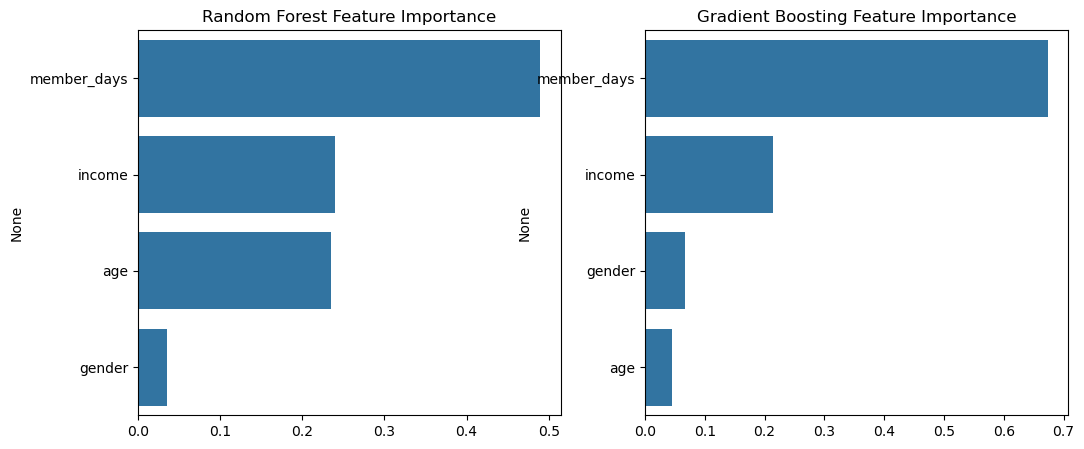

In [21]:
feat_imp_rf = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
feat_imp_gb = pd.Series(gb_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.barplot(x=feat_imp_rf.values, y=feat_imp_rf.index)
plt.title('Random Forest Feature Importance')

plt.subplot(1,2,2)
sns.barplot(x=feat_imp_gb.values, y=feat_imp_gb.index)
plt.title('Gradient Boosting Feature Importance')
plt.show()

# Classification

## Model Training

In [22]:
df['offer_completed'] = (df['offer_completed']>0).astype(int)

In [23]:
df

,id,age,income,member_days,offer_completed,offer_received,gender,offer_completed_rate
0,0009655768c64bdeb2e877511632db8f,33,72000.0,3243,1,5,1,0.60
1,0011e0d4e6b944f998e987f904e8c1e5,40,57000.0,2980,1,5,2,0.60
2,0020c2b971eb4e9188eac86d93036a77,59,90000.0,3656,1,5,0,0.60
3,0020ccbbb6d84e358d3414a3ff76cffd,24,60000.0,3404,1,4,0,0.75
4,003d66b6608740288d6cc97a6903f4f0,26,73000.0,3182,1,5,0,0.60
...,...,...,...,...,...,...,...,...
14820,fff3ba4757bd42088c044ca26d73817a,69,83000.0,3822,1,6,0,0.50
14821,fff7576017104bcc8677a8d63322b5e1,71,73000.0,3050,1,5,1,0.60
14822,fff8957ea8b240a6b5e634b6ee8eafcf,71,56000.0,2940,0,3,1,0.00
14823,fffad4f4828548d1b5583907f2e9906b,34,34000.0,3331,1,4,1,0.75


In [24]:
# Features 
features = ['age', 'income', 'member_days', 'gender']
X = df[features]

# Target
y = df['offer_completed']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=500)
lr_model.fit(X_train_scaled, y_train)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

# Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)

GradientBoostingClassifier(n_estimators=200, random_state=42)

In [28]:
# Probabilities (for ranking or thresholding)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:,1]
y_proba_rf = rf_model.predict_proba(X_test)[:,1]
y_proba_gb = gb_model.predict_proba(X_test)[:,1]

# Predicted classes
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test)
y_pred_gb = gb_model.predict(X_test)

## Evaluation

In [29]:
def evaluate_model(y_true, y_pred, y_proba, model_name):
    print(f"--- {model_name} ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_proba))
    print("\n")

In [30]:
evaluate_model(y_test, y_pred_lr, y_proba_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_rf, y_proba_rf, "Random Forest")
evaluate_model(y_test, y_pred_gb, y_proba_gb, "Gradient Boosting")

--- Logistic Regression ---
Accuracy: 0.8128161888701517
Precision: 0.8195697432338653
Recall: 0.985398414685023
F1 Score: 0.8948664519795416
ROC-AUC: 0.7782314454100488


--- Random Forest ---
Accuracy: 0.793929173693086
Precision: 0.8382575757575758
Recall: 0.9232373800584064
F1 Score: 0.8786976374826285
ROC-AUC: 0.7597337781381657


--- Gradient Boosting ---
Accuracy: 0.812141652613828
Precision: 0.829041487839771
Recall: 0.9670421360033375
F1 Score: 0.8927402272289621
ROC-AUC: 0.8025844365315798




# Refinement

In [41]:
print("=== Logistic Regression — C (Regularisation) Tuning ===")
for C in [0.01, 0.1, 1.0, 10.0]:
    m = LogisticRegression(max_iter=500, C=C)
    m.fit(X_train_scaled, y_train)
    pred = m.predict(X_test_scaled)
    proba = m.predict_proba(X_test_scaled)[:,1]
    print(f"  C={C:5.2f} → Accuracy: {accuracy_score(y_test, pred):.4f} | F1: {f1_score(y_test, pred):.4f} | ROC-AUC: {roc_auc_score(y_test, proba):.4f}")

print("\n=== Random Forest — n_estimators Tuning ===")
for n in [50, 100, 150, 200]:
    m = RandomForestClassifier(n_estimators=n, random_state=42)
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    proba = m.predict_proba(X_test)[:,1]
    print(f"  n_estimators={n:3d} → Accuracy: {accuracy_score(y_test, pred):.4f} | F1: {f1_score(y_test, pred):.4f} | ROC-AUC: {roc_auc_score(y_test, proba):.4f}")

print("\n=== Gradient Boosting — learning_rate & max_depth Tuning ===")
for lr in [0.05, 0.1, 0.2]:
    for depth in [2, 3, 5]:
        m = GradientBoostingClassifier(n_estimators=200, learning_rate=lr, max_depth=depth, random_state=42)
        m.fit(X_train, y_train)
        pred = m.predict(X_test)
        proba = m.predict_proba(X_test)[:,1]
        print(f"  lr={lr} | depth={depth} → Accuracy: {accuracy_score(y_test, pred):.4f} | F1: {f1_score(y_test, pred):.4f} | ROC-AUC: {roc_auc_score(y_test, proba):.4f}")


=== Logistic Regression — C (Regularisation) Tuning ===
  C= 0.01 → Accuracy: 0.8132 | F1: 0.8957 | ROC-AUC: 0.7776
  C= 0.10 → Accuracy: 0.8121 | F1: 0.8946 | ROC-AUC: 0.7782
  C= 1.00 → Accuracy: 0.8128 | F1: 0.8949 | ROC-AUC: 0.7782
  C=10.00 → Accuracy: 0.8125 | F1: 0.8947 | ROC-AUC: 0.7782

=== Random Forest — n_estimators Tuning ===
  n_estimators= 50 → Accuracy: 0.7879 | F1: 0.8743 | ROC-AUC: 0.7522
  n_estimators=100 → Accuracy: 0.7943 | F1: 0.8784 | ROC-AUC: 0.7546
  n_estimators=150 → Accuracy: 0.7939 | F1: 0.8785 | ROC-AUC: 0.7583
  n_estimators=200 → Accuracy: 0.7939 | F1: 0.8787 | ROC-AUC: 0.7597

=== Gradient Boosting — learning_rate & max_depth Tuning ===
  lr=0.05 | depth=2 → Accuracy: 0.8185 | F1: 0.8969 | ROC-AUC: 0.8075
  lr=0.05 | depth=3 → Accuracy: 0.8162 | F1: 0.8957 | ROC-AUC: 0.8068
  lr=0.05 | depth=5 → Accuracy: 0.8101 | F1: 0.8910 | ROC-AUC: 0.8007
  lr=0.1 | depth=2 → Accuracy: 0.8162 | F1: 0.8955 | ROC-AUC: 0.8063
  lr=0.1 | depth=3 → Accuracy: 0.8121 | F1